<a href="https://colab.research.google.com/github/alracey/level4-project/blob/Higher-dimensions/piecewise_linear_pytorch_2d_opt_bins_coupling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preliminaries

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sympy

torch.__version__

'2.11.0+cpu'

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
dtype = torch.float32

Using device: cpu


NOTE: in this piecewise-linear notebook, any instance of the word 'heights' refers to CDF heights and NOT pdf heights because of the way the code is written.

This section defines the target functions f, the piecewise transform g, and the transformed function h.

In [6]:
sigma = 0.2   #width for Gaussians

In [4]:
def camel(x, y):
  alpha = 0.2
  peak_1 = torch.exp(-(((x-1/4)**2 + (y-1/4)**2) / alpha**2))
  peak_2 = torch.exp(-(((x-3/4)**2 + (y-3/4)**2) / alpha**2))

  return (0.5 * (alpha * torch.sqrt(torch.tensor(torch.pi)))**(-2)) * (peak_1 + peak_2)

In [7]:
def f_3d(x, y, z):
  return torch.exp(-(((x-0.5)**2 + (y-0.5)**2 + (z-0.5)**2) / (2*(sigma)**2)))

In [8]:
def gauss(x, y):
  return torch.exp(-(((x-0.5)**2 + (y-0.5)**2) / (2*(sigma)**2)))

In [9]:
def ring(x, y, r0=0.3, sigma = 0.05, centre=(0.5, 0.5)):

  cx, cy = centre
  r = torch.sqrt((x-cx)**2 + (y-cy)**2)
  return torch.exp(-((r-r0)**2 / (2*(sigma)**2)))


tensor(1.1129)


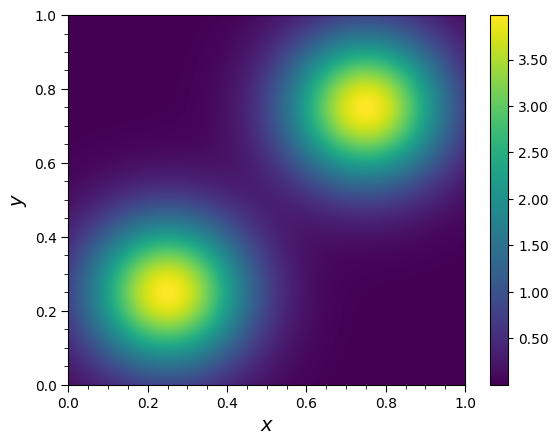

In [5]:
def plot_f(f, N):
  xs, ys = torch.linspace(0, 1, N), torch.linspace(0, 1, N)
  X, Y = torch.meshgrid(xs, ys, indexing='ij')
  Z = f(X, Y)
  print(torch.var(Z))

  fig, ax = plt.subplots()

  pcm = plt.pcolormesh(X, Y, Z, cmap='viridis', shading='auto')

  ax.set_xlabel("$x$", fontsize=14)
  ax.set_ylabel("$y$", fontsize=14)

  ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=10)
  ax.tick_params(axis="both", which="minor", direction="out", length=3)
  ax.minorticks_on()

  cbar = plt.colorbar(pcm, ax=ax)
  cbar.formatter = ticker.FormatStrFormatter('%.2f')
  cbar.update_ticks()

  ax.set_xlim(0.0, 1.0)
  ax.set_ylim(0.0, 1.0)

  plt.show()
  return fig

test = plot_f(camel, 1000)

tensor(0.1111)


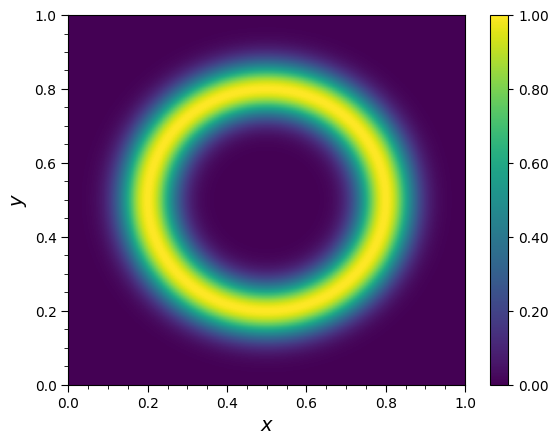

In [10]:
test_2 = plot_f(ring, 1000)

In [11]:
def grid_points(n, density):

  npts = n
  grid = torch.empty(density*npts,2)

  for vi in range(int(density/2)):
    beg = vi*npts
    end = beg+npts
    grid[beg:end,0] = vi/int(((density/2) - 1))
    grid[beg:end,1] = torch.linspace(0, 1, npts)

  for hi in range(int(density/2)):
    beg = (int(density/2)+hi)*npts
    end = beg+npts
    grid[beg:end,1] = hi/int(((density/2)-1))
    grid[beg:end,0] = torch.linspace(0, 1, npts)

  return grid

In [12]:
def plot_f_scatter(f, n, density):

  fig, ax = plt.subplots(figsize=(7.5,6))
  points = grid_points(n, density)
  x = points[:,0]
  y = points[:,1]
  z = f(x, y)

  scat = ax.scatter(
    x,
    y,
    c=z,
    s=6,
    cmap='viridis'
  )
  ax.set_xlabel("$x$", fontsize=14)
  ax.set_ylabel("$y$", fontsize=14)

  ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=16)
  ax.tick_params(axis="both", which="minor", direction="out", length=3)
  ax.minorticks_on()

  cbar = plt.colorbar(scat, ax=ax)
  cbar.formatter = ticker.FormatStrFormatter('%.2f')
  cbar.ax.tick_params(labelsize=16)
  cbar.update_ticks()

  ax.set_xlim(0.0, 1.0)
  ax.set_ylim(0.0, 1.0)

  plt.show()

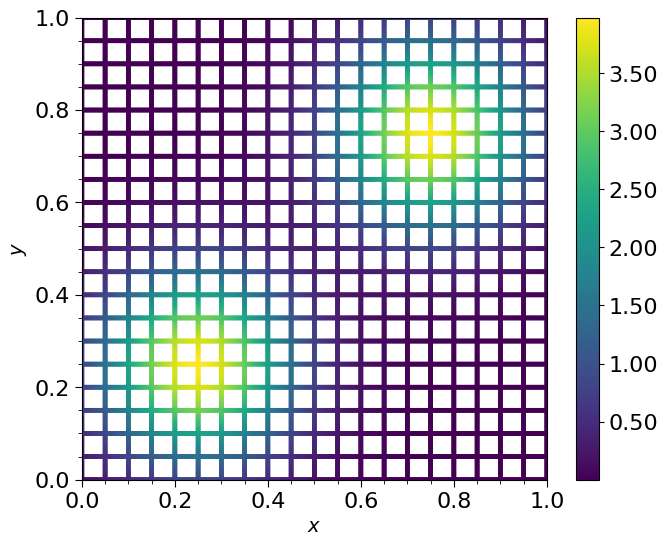

In [13]:
plot_f_scatter(camel, 500, 42)


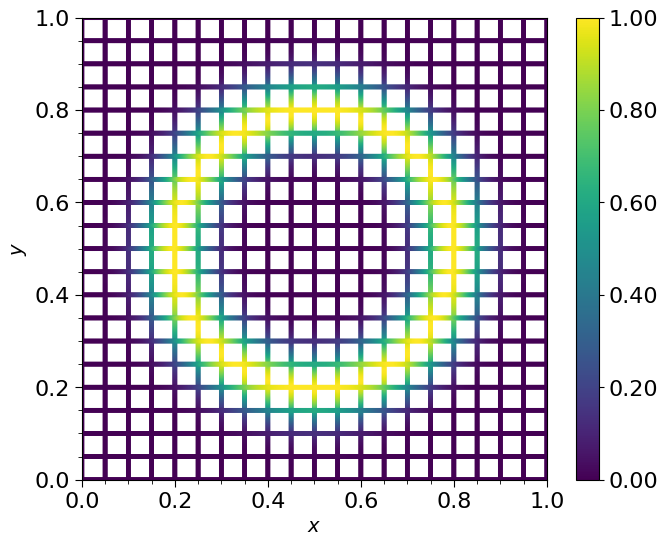

In [14]:
plot_f_scatter(ring, 500, 42)

In [ ]:
def g_old(x, params, bins):

  '''
  New transform function generalised to deal with batches from NN.
  Parameters/bins can still be specified in the old way for testing by using an expanded tensor.
  x:      (B. D)
  params: (B, D, K-1)
  bins:   (B, D, K+1)
  '''

  device = x.device
  dtype = x.dtype

  B, D = x.shape
  K = params.size(-1) + 1

  #cdf heights
  zeros = torch.zeros((B, D, 1), device=device, dtype=dtype)
  ones = torch.ones((B, D, 1), device=device, dtype=dtype)
  heights = torch.cat([zeros, params, ones], dim=-1)

  # Find bin index via comparison
  # Compare x with bin edges

  x_expanded = x.unsqueeze(-1)  # (B, D, 1)

  # Count how many bin edges x is greater than
  i_values = torch.sum(x_expanded >= bins, dim=-1) - 1  # (B, D)
  i_values = torch.clamp(i_values, min=0)

  #i = torch.clamp(i, 0, K-1)
  i_values_right = torch.clamp(i_values + 1, max=K)

  i_unsq = i_values.unsqueeze(-1)
  i_right_unsq = i_values_right.unsqueeze(-1)   #(B, D, 1)

  x_left  = torch.gather(bins, dim=2, index=i_unsq).squeeze(-1)   #(B, D, 1) ---> (B, D)
  x_right = torch.gather(bins, dim=2, index=i_right_unsq).squeeze(-1)

  y_left  = torch.gather(heights, dim=2, index=i_unsq).squeeze(-1)
  y_right = torch.gather(heights, dim=2, index=i_right_unsq).squeeze(-1)    #(B, D, 1) ---> (B, D)

  slope = (y_right - y_left) / (x_right - x_left)
  y = y_left + slope * (x - x_left)

  return y    #(B, D)

In [15]:
def g_coupling(x_A, x_B, heights, bins):

  '''
  Coupling-layer compatible transform.  Preserves x_A, transforms x_B.
  New transform function generalised to deal with batches from NN.
  Parameters/bins can still be specified in the old way for testing by using an expanded tensor.
  x_A:      (B, D_A)
  x_B:      (B, D_B)
  D_A, D_B are the dimensionalities of the two partitions.  Both can be greater than 1.
  D_A, D_B pre-determined by specific mask of coupling layer.
  heights: (B, D_B, K-1)
  bins:   (B, D_B, K+1)
  '''

  device = x_B.device
  dtype = x_B.dtype

  B, D_B = x_B.shape
  K = heights.size(-1) + 1

  #cdf heights
  zeros = torch.zeros((B, D_B, 1), device=device, dtype=dtype)
  ones = torch.ones((B, D_B, 1), device=device, dtype=dtype)
  cdf_heights = torch.cat([zeros, heights, ones], dim=-1)

  #----------------APPLY TRANSFORM TO x_B-----------------------------------#
  # Compare x_B with bin edges

  xB_expanded = x_B.unsqueeze(-1)  # (B, D_B, 1)

  # Count how many bin edges x_B is greater than
  i_values = torch.sum(xB_expanded >= bins, dim=-1) - 1  # (B, D_B)
  i_values = torch.clamp(i_values, min=0, max=K-1)

  i_values_right = i_values + 1

  i_unsq = i_values.unsqueeze(-1)
  i_right_unsq = i_values_right.unsqueeze(-1)   #(B, D_B, 1)

  x_left  = torch.gather(bins, dim=2, index=i_unsq).squeeze(-1)   #(B, D_B, 1) ---> (B, D_B)
  x_right = torch.gather(bins, dim=2, index=i_right_unsq).squeeze(-1)

  y_left  = torch.gather(cdf_heights, dim=2, index=i_unsq).squeeze(-1)
  y_right = torch.gather(cdf_heights, dim=2, index=i_right_unsq).squeeze(-1)    #(B, D_B, 1) ---> (B, D_B)

  slope = (y_right - y_left) / (x_right - x_left)
  y_B = y_left + slope * (x_B - x_left)

  #------------------------------------------------------------------------#

  y_A = x_A

  return y_A, y_B

In [16]:
def expand_params(B, params):   #copies parameters to fit batch size
  '''
  params.shape = (D, K-1)
  returns (B, D, K-1)
  '''

  D = params.size(0)
  K = params.size(1) + 1
  expanded_params = torch.empty(B, D, K-1)
  expanded_params[:, :] = params
  return expanded_params

def expand_edges(B, edges):   #copies bin edges to fit batch size
  '''
  edges.shape = (D, K+1)
  returns (B, D, K+1)
  '''

  D = edges.size(0)
  K = edges.size(1) -1
  expanded_edges = torch.empty(B, D, K+1)
  expanded_edges[:, :] = edges
  return expanded_edges

#params = torch.rand(D, 7)
#edges = torch.rand(D, 8)
#print(expand_params(10, params))
#print(expand_edges(10, edges))

Defining functions for obtaining parameters and widths appropriate for the functions, from raw ones

In [17]:
def raw_heights_to_params(raw_heights):
    """
    raw_heights: (B, D, K-1)

    Returns:
        params: (B, D, K-1)
        strictly increasing in last dimension,
        between 0 and 1.
    """

    device = raw_heights.device
    dtype = raw_heights.dtype

    B, D, K_minus_1 = raw_heights.shape

    # Append extra zero for normalization
    zeros = torch.zeros((B, D, 1), device=device, dtype=dtype)

    u_ext = torch.cat([raw_heights, zeros], dim=-1)  # (B, D, K)

    # Softmax along bin dimension
    w = torch.softmax(u_ext, dim=-1)  # (B, D, K)

    # Cumulative sum to get CDF
    ys = torch.cumsum(w, dim=-1)  # (B, D, K)

    # Remove last entry (which equals 1)
    return ys[..., :-1]  # (B, D, K-1)



def raw_widths_to_bins(raw_widths):
    """
    raw_widths: (B, D, K)

    Returns:
        bins: (B, D, K+1)
        increasing,
        starting at 0 and ending at 1.
    """

    device = raw_widths.device
    dtype = raw_widths.dtype

    # Softmax so widths sum to 1
    widths = torch.softmax(raw_widths, dim=-1)  # (B, D, K)

    # Cumulative sum gives interior edges
    int_edges = torch.cumsum(widths, dim=-1)  # (B, D, K)

    # Prepend zero
    zeros = torch.zeros((*int_edges.shape[:2], 1),
                        device=device, dtype=dtype)

    bins = torch.cat([zeros, int_edges], dim=-1)  # (B, D, K+1)

    return bins

In [18]:
def inverse_transform(y_B, B_dims, heights, bins):

  '''
  Computes the inverse transform and associated Jacobian.
  Non-uniform bins permitted.
  y_B:      (B, D_B)
  '''

  device = y_B.device
  dtype = y_B.dtype

  B, D_B = y_B.shape
  K = heights.size(-1) + 1

  #cdf heights
  zeros = torch.zeros((B, D_B, 1), device=device, dtype=dtype)
  ones = torch.ones((B, D_B, 1), device=device, dtype=dtype)
  cdf_heights = torch.cat([zeros, heights, ones], dim=-1)

  #---------y_A = x_A so only need to do inverse for y_B--------------------#

  #sort y_B by comparing y_B with cdf heights
  yB_expanded = y_B.unsqueeze(-1)  # (B, D_B, 1)

  j_values = torch.sum(yB_expanded >= cdf_heights, dim=-1) - 1  #(B, D_B)
  j_values = torch.clamp(j_values, min=0, max=K-1)

  j_values_right = j_values + 1

  j_unsq = j_values.unsqueeze(-1)
  j_right_unsq = j_values_right.unsqueeze(-1)

  x_left = torch.gather(bins, dim=2, index=j_unsq).squeeze(-1)    #(B, D_B, 1) ---> (B, D_B)
  x_right = torch.gather(bins, dim=2, index=j_right_unsq).squeeze(-1)
  y_left = torch.gather(cdf_heights, dim=2, index=j_unsq).squeeze(-1)
  y_right = torch.gather(cdf_heights, dim=2, index=j_right_unsq).squeeze(-1)

  def g_inv(y):

    return x_left + ((x_right - x_left) / (y_right - y_left)) * (y - y_left)    #(B, D_B)

  jacobians = (x_right - x_left) / (y_right - y_left)   #(B, D_B)

  jac_det = jacobians.prod(dim=1)

  return g_inv(y_B), jac_det

Defining the neural networks which return the raw cdf heights and raw bin widths respectively

In [19]:
#neural network for cdf heights V

class flownet_V(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):

    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_size, out_features=hidden_size),
        nn.ReLU(),
        nn.Linear(in_features=hidden_size, out_features=hidden_size),   #only one hidden layer for now
        nn.ReLU(),
        nn.Linear(in_features=hidden_size, out_features=output_size),
    )

  def forward(self, x):
        return self.linear_layer_stack(x)



#neural network for bin widths W

class flownet_W(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):

    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_size, out_features=hidden_size),
        nn.ReLU(),
        nn.Linear(in_features=hidden_size, out_features=hidden_size),   #only one hidden layer for now
        nn.ReLU(),
        nn.Linear(in_features=hidden_size, out_features=output_size),
    )

  def forward(self, x):
        return self.linear_layer_stack(x)

Define a layer class which contains a NN for CDF heights and widths respectively (generalisation of the above), and a composition class which chains together an arbitrary number of coupling layers.

In [20]:
class pwl_layer(nn.Module):
  '''
  A self-contained piecewise-linear coupling layer.
  Includes forward transform, inverse transform and Jacobian determinant functions.
  '''
  def __init__(self, D_A, D_B, A_dims, B_dims, K, hidden_size):

    super().__init__()

    #attributes

    self.D_A = D_A
    self.D_B = D_B
    self.K = K
    self.register_buffer("A_dims", A_dims)
    self.register_buffer("B_dims", B_dims)

    #networks

    self.heights_net = flownet_V(input_size=D_A, hidden_size=hidden_size, output_size=D_B*(K-1))

    self.widths_net = flownet_W(input_size=D_A, hidden_size=hidden_size, output_size=D_B*K)


  def forward(self, x):

    B = x.size(0)

    x_A = x[:, self.A_dims]   #apply mask
    x_B = x[:, self.B_dims]

    raw_heights = self.heights_net(x_A).reshape(B, self.D_B, (self.K - 1))    #evaluate neural networks with x_A
    raw_widths = self.widths_net(x_A).reshape(B, self.D_B, self.K)

    heights = raw_heights_to_params(raw_heights)
    bins = raw_widths_to_bins(raw_widths)

    y_A, y_B = g_coupling(x_A, x_B, heights, bins)    #apply the transform to x_B

    #reconstruct the y vector

    y = torch.zeros_like(x)
    y[:, self.A_dims] = y_A
    y[:, self.B_dims] = y_B

    return y


  def inverse(self, y):

    B = y.size(0)

    y_A = y[:, self.A_dims]
    y_B = y[:, self.B_dims]

    raw_heights = self.heights_net(y_A).reshape(B, self.D_B, (self.K - 1))    #evaluate neural networks with x_A
    raw_widths = self.widths_net(y_A).reshape(B, self.D_B, self.K)

    heights = raw_heights_to_params(raw_heights)
    bins = raw_widths_to_bins(raw_widths)

    x_B, jac_det = inverse_transform(y_B, self.B_dims, heights, bins)
    x_A = y_A

    x = torch.zeros_like(y)
    x[:, self.A_dims] = x_A
    x[:, self.B_dims] = x_B

    return x, jac_det


In [21]:
class Composition(nn.Module):
  '''
  Composes the specified coupling layers and has the same functions as its constitients but generalised.
  '''

  def __init__(self, layers):

    super().__init__()

    self.layers = nn.ModuleList(layers)

  def forward(self, x):

    Y = x

    for layer in self.layers:

      Y = layer(Y)

    return Y

  def inverse(self, y):

    #we need to iterate backwards

    X = y
    jac_dets = torch.ones(y.shape[0], device=y.device, dtype=y.dtype)

    for layer in reversed(list(self.layers)):

      X, jac = layer.inverse(X)
      jac_dets = jac_dets * jac

    return X, jac_dets


In [ ]:
A_dims_test = [torch.tensor([0, 1]),   #A dimensions in first layer
               torch.tensor([2, 3, 1]), #2nd
               torch.tensor([0, 2]),   #3rd
               torch.tensor([1, 3])]  #4th

B_dims_test = [torch.tensor([2, 3]),
               torch.tensor([0]),
               torch.tensor([1, 3]),
               torch.tensor([0, 2])]

print(A_dims_test)
print(A_dims_test[0])
print(len(A_dims_test))
print(A_dims_test[1].size(-1))

[tensor([0, 1]), tensor([2, 3, 1]), tensor([0, 2]), tensor([1, 3])]
tensor([0, 1])
4
3


Now define a function which builds a normalising flow by specifying masks and layers, using the previous objects

In [22]:
def normalising_flow(layer_type, A_dims, B_dims, K, hidden_size):

  '''
  Works for arbitrary dimensions, masks, layers.
  A_dims, B_dims are lists of tensors containing the indices of the relevant dimensions - the maskings.
  K is the number of bins for the piecewise-linear transformation.
  hidden_size is the number of nodes in the hidden layer(s) of the neural networks.
  Returns the Composition object corresponding to the inputs.
  '''

  num_layers = len(A_dims)
  layers = []

  for i in range(num_layers):   #build layers

    D_A = A_dims[i].size(-1)    #get D_A, D_B
    D_B = B_dims[i].size(-1)

    layer = layer_type(
        D_A = D_A,
        D_B = D_B,
        A_dims = A_dims[i],
        B_dims = B_dims[i],
        K = K,                  #using same K for each layer for now
        hidden_size = hidden_size
    )

    layers.append(layer)


  c = Composition(layers)
  return c


Define training loop(s)

In [23]:
#NEW TRAINING LOOP FOR COMPOSITION

def train_loop_complete(f, D, layer_type, A_dims, B_dims, K, hidden_size, N, epochs, lr, device, ticker):    #using same K for each layer for now

  #instantiate flow with specified parameters
  flow = normalising_flow(
      layer_type,
      A_dims=A_dims,
      B_dims=B_dims,
      K=K,
      hidden_size=hidden_size
  )

  #optimiser
  optimiser = torch.optim.Adam([
      {"params": flow.parameters(), "lr": lr}
      ])

  loss_values = torch.zeros(epochs, device=device)

  for epoch in range(epochs):

    V = torch.rand(N, D)

    #inverse, jacobian determinants
    X, jac_dets = flow.inverse(V)

    #compute new function
    X = X.T
    h_eval = f(*X) * torch.abs(jac_dets)

    #compute loss
    loss = torch.var(h_eval)
    loss_values[epoch] = loss.detach()

    optimiser.zero_grad()

    loss.backward()

    optimiser.step()

    if ticker and epoch % 20 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.8e}")
      print("Mean value: ", torch.mean(h_eval).detach().item())

  final_loss = loss.detach()

  return final_loss, loss_values, flow


Testing the composition method

In [24]:
#testing new loop - define parameters first

A_dims = [torch.tensor([0]),
          torch.tensor([1]),
          torch.tensor([0]),
          torch.tensor([1])]

B_dims = [torch.tensor([1]),
          torch.tensor([0]),
          torch.tensor([1]),
          torch.tensor([0])]

In [26]:
#train

final_loss, loss_values, flow = train_loop_complete(
    layer_type=pwl_layer,
    f=camel,
    D=2,
    A_dims=A_dims,
    B_dims=B_dims,
    K=32,
    hidden_size=16,
    N=10_000,
    epochs=1500,
    lr=1e-4,
    device='cpu',
    ticker=False
)

In [29]:
#evaluate using my own grid

Y = grid_points(1000, density=42)

X, jacs = flow.inverse(Y)
X, jacs = X.detach(), jacs.detach()
X = X.T

h = camel(*X) * torch.abs(jacs)


In [27]:
#check integral
N=100000
y_test = torch.rand(N, 2)
x_test, jacobian = flow.inverse(y_test)
x_test = x_test.detach().T

h_evals = camel(*x_test) * jacobian
print(h_evals.shape)

H_est = torch.mean(h_evals)
alpha_H = torch.std(h_evals) / torch.sqrt(torch.tensor(N))

print(f'H estimate = {H_est} ± {alpha_H}')

torch.Size([100000])
H estimate = 0.9241843819618225 ± 0.0017953756032511592


Plot distortion of grid under layers

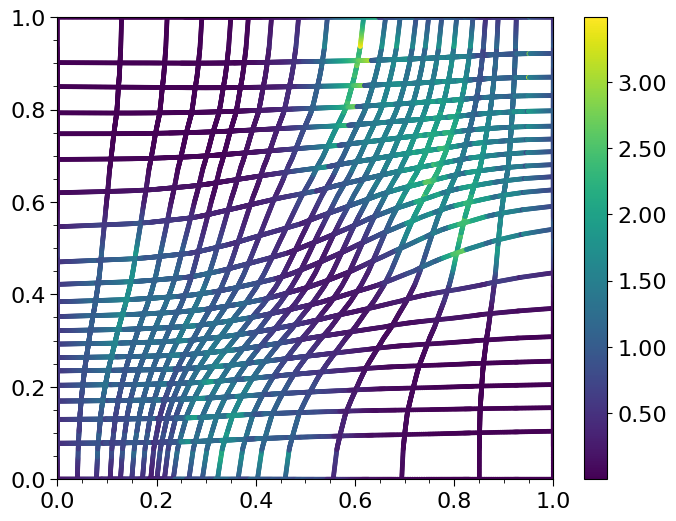

In [30]:
fig, ax = plt.subplots(figsize=(8,6))
plot = ax.scatter(
  X[0].squeeze().cpu(),
  X[1].squeeze().cpu(),
  c=h.cpu(),
  s=6,
  cmap='viridis'
)
#ax.set_xlabel("$y_1$", fontsize=18)
#ax.set_ylabel("$y_2$", fontsize=18)

ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=16)
ax.tick_params(axis="both", which="minor", direction="out", length=3)
ax.minorticks_on()

cbar = plt.colorbar(plot, ax=ax)
cbar.formatter = ticker.FormatStrFormatter('%.2f')
cbar.ax.tick_params(labelsize=16)
cbar.update_ticks()

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)

plt.show()

Visualise the distribution in "x" space induced by the flow from sampling uniformly in "y" space

In [31]:
num_samples = 200000

Y = torch.rand(num_samples, 2).to(device)

X, jacobians = flow.inverse(Y)
X = X.detach().cpu()

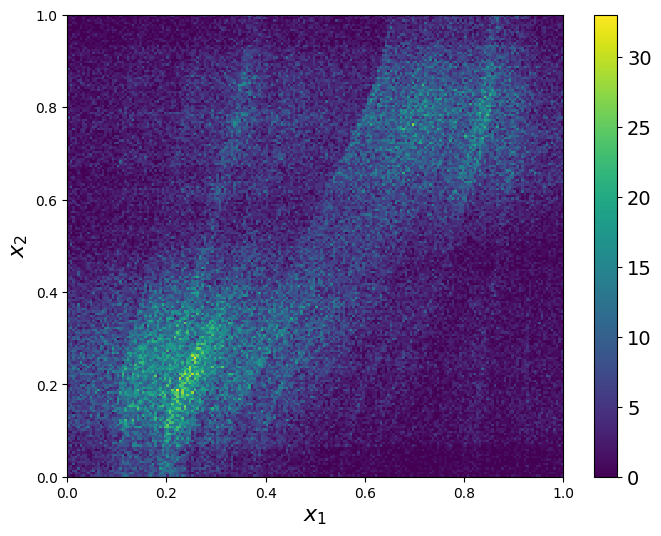

In [32]:
fig, ax = plt.subplots(figsize=(8,6))

plot = ax.hist2d(
      X[:,0],
      X[:,1],
      bins=200,
      range=[[0,1],[0,1]],
      cmap = 'viridis'
)

cbar = plt.colorbar(plot[3], ax=ax)
cbar.ax.tick_params(labelsize=14)
cbar.update_ticks()

ax.set_xlabel("$x_1$", fontsize=16)
ax.set_ylabel("$x_2$", fontsize=16)

plt.show()

Plot importance weights

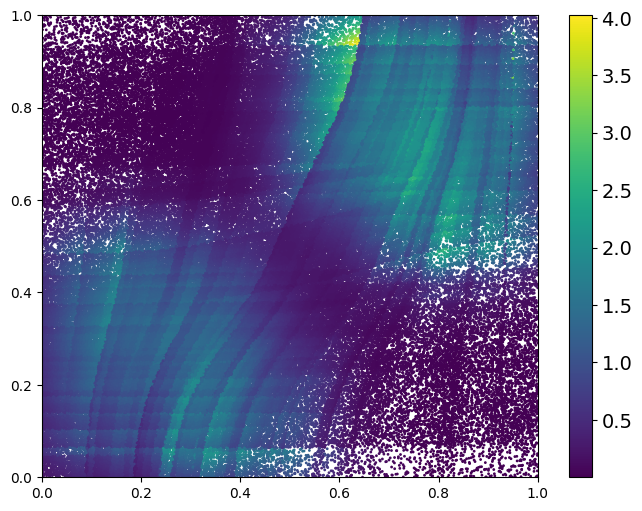

In [33]:
weights = camel(X[:,0], X[:,1]) * torch.abs(jacobians)
weights = weights.detach().cpu()

fig, ax = plt.subplots(figsize=(8,6))

sc = ax.scatter(
    X[:,0],
    X[:,1],
    c=weights,
    s=1,
    cmap="viridis"
)

cbar = plt.colorbar(sc, ax=ax)
cbar.ax.tick_params(labelsize=14)
cbar.update_ticks()

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
plt.show()

Analyis section

Loss vs epoch for different K

In [ ]:
#generate data

A_dims_test = [torch.tensor([0]),
          torch.tensor([1])]
B_dims_test = [torch.tensor([1]),
          torch.tensor([0])]

K_s = [2, 4, 8, 16, 32, 64, 128]
epochs = 1000
loss_values = torch.zeros((len(K_s), epochs), device=device, dtype=dtype)

results = {}  # K -> loss tensor

for K in K_s:
    _, losses, _ = train_loop_complete(
     f=camel,
     D=2,
     layer_type=pwl_layer,
     A_dims=A_dims_test,
     B_dims=B_dims_test,
     K=K,
     hidden_size=16,
     N=10_000,
     epochs=epochs,
     lr=3e-4,
     device=device,
     ticker=False
    )

    results[K] = losses.detach().cpu()

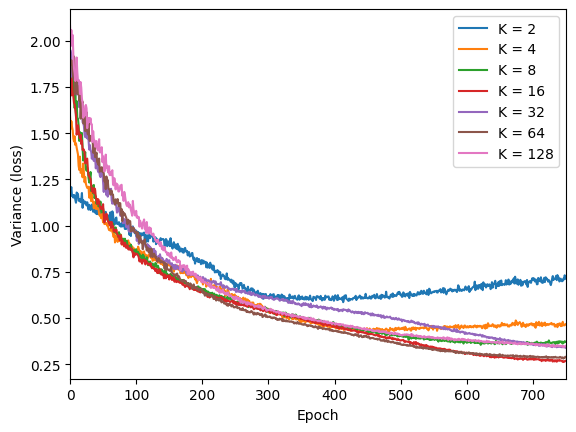

In [ ]:
#plotting for early stopping enabled

plt.figure()

for K, losses in results.items():
  epochs_plot = torch.arange(len(losses))
  plt.plot(epochs_plot, losses.numpy(), label=f"K = {K}")

plt.xlabel("Epoch")
plt.ylabel("Variance (loss)")
#plt.yscale("log")
plt.xlim(0, 750)
plt.legend()
plt.show()

Loss vs K

In [ ]:
#generate data

Ks = range(2, 129)
vars = torch.zeros(len(Ks), device=device)
i=0

for K in Ks:
  result, _, _ = train_loop_complete(
      f=camel,
      D=2,
      layer_type=pwl_layer,
      A_dims=A_dims_test,
      B_dims=B_dims_test,
      K=K,
      hidden_size=16,
      N=10_000,
      epochs=1000,
      lr=3e-4,
      device=device,
      ticker=False
  )

  vars[i] = result.reshape(1) # Reshape scalar to a 1D tensor
  i += 1

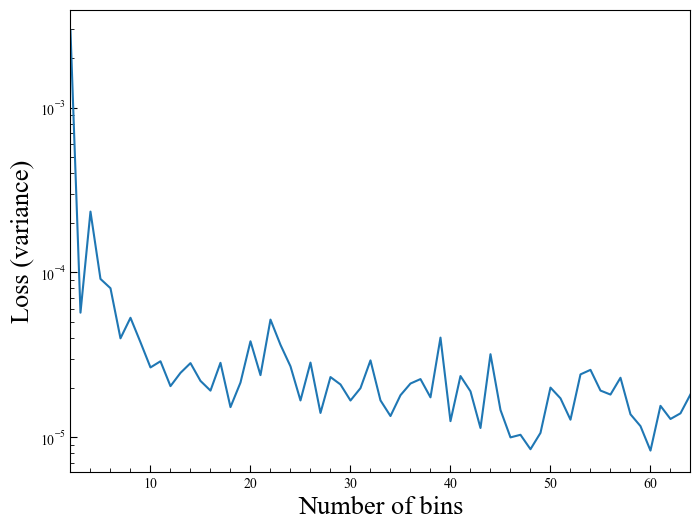

tensor(1.8189e-05)


In [ ]:
#plotting

fig, ax = plt.subplots(figsize=(8,6))

ax.plot(Ks, vars.detach().numpy())  # Detach and convert to numpy for plotting

ax.set_xlabel("Number of bins", fontsize=19)
ax.set_ylabel("Loss (variance)", fontsize=19)

ax.tick_params(axis="both", which="major", direction="in", length=5, labelsize=10)
ax.tick_params(axis="both", which="minor", direction="in", length=3)
ax.minorticks_on()

ax.set_xlim(2, 64)
plt.yscale('log')
plt.show()
print(vars[-1])     #check accuracy